# Cryptocurrency Price Prediction with Machine Learning

In [2]:
import pandas as pd
import yfinance as yf
from datetime import date, timedelta

today = date.today()
end_date = today.strftime("%Y-%m-%d")
start_date = (today - timedelta(days=768)).strftime("%Y-%m-%d")

# 1. Download data
data = yf.download('BTC-USD', start=start_date, end=end_date, progress=False)

# 2. Flatten the MultiIndex columns
# This converts ('Close', 'BTC-USD') into just 'Close'
data.columns = data.columns.get_level_values(0)

# 3. Create the Date column
data["Date"] = data.index

# 4. Select columns safely
# We check if 'Adj Close' exists to avoid another KeyError
available_cols = ["Date", "Open", "High", "Low", "Close", "Volume"]
if "Adj Close" in data.columns:
    available_cols.insert(5, "Adj Close")

data = data[available_cols]
data.reset_index(drop=True, inplace=True)

print(data.head())

Price       Date          Open          High           Low         Close  \
0     2024-03-01  61168.062500  63155.101562  60802.527344  62440.632812   
1     2024-03-02  62431.652344  62458.699219  61657.289062  62029.847656   
2     2024-03-03  62031.578125  63230.210938  61435.023438  63167.371094   
3     2024-03-04  63137.003906  68537.031250  62386.519531  68330.414062   
4     2024-03-05  68341.054688  69170.625000  59323.910156  63801.199219   

Price        Volume  
0       40186368423  
1       23888473685  
2       26253811450  
3       70670471105  
4      102802940877  


In [3]:
print(data.head())

Price       Date          Open          High           Low         Close  \
0     2024-03-01  61168.062500  63155.101562  60802.527344  62440.632812   
1     2024-03-02  62431.652344  62458.699219  61657.289062  62029.847656   
2     2024-03-03  62031.578125  63230.210938  61435.023438  63167.371094   
3     2024-03-04  63137.003906  68537.031250  62386.519531  68330.414062   
4     2024-03-05  68341.054688  69170.625000  59323.910156  63801.199219   

Price        Volume  
0       40186368423  
1       23888473685  
2       26253811450  
3       70670471105  
4      102802940877  


In [4]:
print(data.tail())

Price       Date          Open          High           Low         Close  \
763   2026-04-03  66889.015625  67296.234375  66281.539062  66931.101562   
764   2026-04-04  66938.648438  67515.015625  66769.640625  67290.515625   
765   2026-04-05  67291.195312  69087.656250  66610.632812  68981.898438   
766   2026-04-06  68982.914062  70305.421875  68347.078125  68859.828125   
767   2026-04-07  68859.375000  72732.429688  67740.507812  71940.703125   

Price       Volume  
763    22815543346  
764    15878814963  
765    22972648674  
766    39542143229  
767    44650511480  


In [5]:
data.shape

(768, 6)

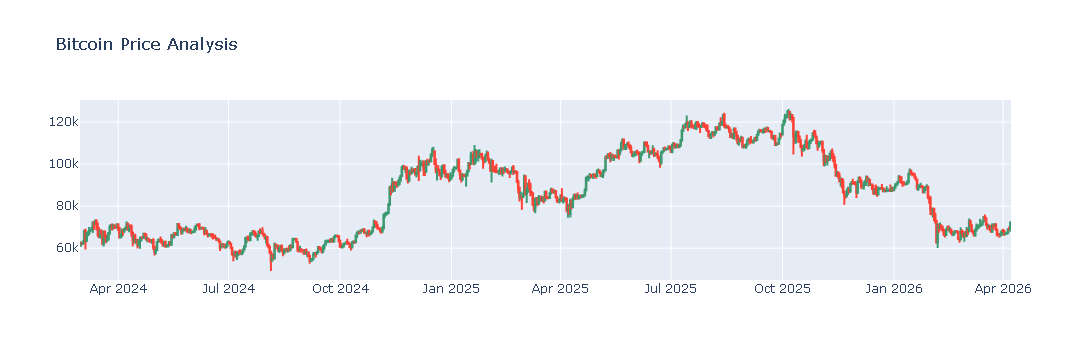

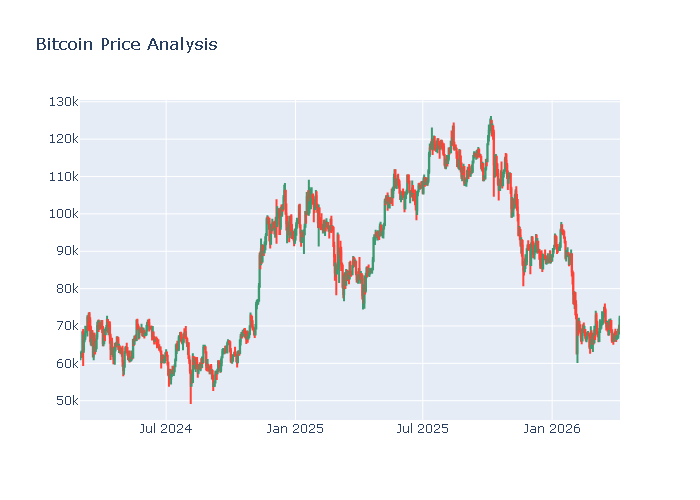

In [13]:
import plotly.graph_objects as go
figure = go.Figure(data=[go.Candlestick(x=data["Date"],
                                        open=data["Open"], 
                                        high=data["High"],
                                        low=data["Low"], 
                                        close=data["Close"])])
figure.update_layout(title = "Bitcoin Price Analysis", 
                     xaxis_rangeslider_visible=False)
figure.show()
figure.show("png")

In [7]:
correlation = data.corr()
print(correlation["Close"].sort_values(ascending=False))

Price
Close     1.000000
High      0.997559
Low       0.997209
Open      0.994306
Date      0.515559
Volume    0.462744
Name: Close, dtype: float64


In [8]:
pip install autots

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 11.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [9]:
from autots import AutoTS
model = AutoTS(forecast_length=30, frequency='infer', ensemble='simple')
model = model.fit(data, date_col='Date', value_col='Close', id_col=None)
prediction = model.predict()
forecast = prediction.forecast
print(forecast)

Using 2 cpus for n_jobs.
Data frequency is: D, used frequency is: D
profile_time_series failed during fit_data: KeyError("None of ['SERIES'] are in the columns")
Model Number: 1 with model AverageValueNaive in generation 0 of 25
Model Number: 2 with model AverageValueNaive in generation 0 of 25
Model Number: 3 with model AverageValueNaive in generation 0 of 25
Model Number: 4 with model DatepartRegression in generation 0 of 25
Model Number: 5 with model ETS in generation 0 of 25
Model Number: 6 with model GLM in generation 0 of 25
Model Number: 7 with model GLS in generation 0 of 25
Model Number: 8 with model LastValueNaive in generation 0 of 25
Model Number: 9 with model LastValueNaive in generation 0 of 25
Model Number: 10 with model LastValueNaive in generation 0 of 25
Model Number: 11 with model SeasonalNaive in generation 0 of 25
Model Number: 12 with model SeasonalNaive in generation 0 of 25
Model Number: 13 with model VAR in generation 0 of 25
Template Eval Error: ValueError('On

C:\Users\isha\miniconda3\envs\financials_env\lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\isha\miniconda3\envs\financials_env\lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Model Number: 29 with model Cassandra in generation 0 of 25
Model Number: 30 with model Cassandra in generation 0 of 25
Model Number: 31 with model DMD in generation 0 of 25
Model Number: 32 with model DMD in generation 0 of 25
Model Number: 33 with model SectionalMotif in generation 0 of 25
Model Number: 34 with model ARDL in generation 0 of 25
Model Number: 35 with model FFT in generation 0 of 25
Model Number: 36 with model BasicLinearModel in generation 0 of 25
Template Eval Error: ValueError('matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 738 is different from 2003)') in model 36 in generation 0: BasicLinearModel
Model Number: 37 with model BasicLinearModel in generation 0 of 25
Model Number: 38 with model SeasonalityMotif in generation 0 of 25
Model Number: 39 with model BasicLinearModel in generation 0 of 25
Model Number: 40 with model BallTreeRegressionMotif in generation 0 of 25
Model Number: 41 with model Date

C:\Users\isha\miniconda3\envs\financials_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.163e+10, tolerance: 1.743e+07
  model = cd_fast.enet_coordinate_descent(


Model Number: 52 with model LastValueNaive in generation 0 of 25
Model Number: 53 with model AverageValueNaive in generation 0 of 25
Model Number: 54 with model GLS in generation 0 of 25
Model Number: 55 with model SeasonalNaive in generation 0 of 25
Model Number: 56 with model VAR in generation 0 of 25
Template Eval Error: ValueError('Only gave one variable to VAR') in model 56 in generation 0: VAR
Model Number: 57 with model WindowRegression in generation 0 of 25
Template Eval Error: ModuleNotFoundError("No module named 'lightgbm'") in model 57 in generation 0: WindowRegression
Model Number: 58 with model DatepartRegression in generation 0 of 25
Template Eval Error: ValueError('Input X contains NaN.\nElasticNet does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data,

...

85 - Ensemble with avg smape 6.66 in 0.42s: 
86 - Ensemble with avg smape 6.65 in 0.43s: 
87 - Ensemble with avg smape 7.1 in 0.45s: 
88 - Ensemble with avg smape 8.32 in 0.46s: 
89 - Ensemble with avg smape 7.53 in 0.47s: 
90 - Ensemble with avg smape 7.02 in 0.49s: 
Postprocessing Error: Exception("Transformer HistoricValues failed on fit from params fake_date {'0': {'rows': 1, 'lag': 1, 'method': 'additive', 'strength': 1.0, 'first_value_only': False, 'threshold': 10, 'threshold_method': 'mean'}, '1': {'window': 28}} with error KeyError('2')") in model 90 postprocessor 0: Ensemble
91 - Ensemble with avg smape 6.97 in 0.50s: 
92 - Ensemble with avg smape 6.7 in 0.52s: 
93 - Ensemble with avg smape 6.57 in 0.54s: 
94 - Ensemble with avg smape 6.52 in 0.56s: 
95 - Ensemble with avg smape 7.18 in 0.62s: 
96 - Ensemble with avg smape 7.32 in 0.65s: 
97 - Ensemble with avg smape 6.65 in 0.67s: 
98 - Ensemble with avg smape 6.75 in 0.71s: 
Model Number: 99 of 9 with model Ensemble for Vali

C:\Users\isha\miniconda3\envs\financials_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\isha\miniconda3\envs\financials_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\isha\miniconda3\envs\financials_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\isha\miniconda3\envs\financials_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\isha\miniconda3\envs\financials_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


85 - Ensemble with avg smape 2.36 in 0.42s: 
86 - Ensemble with avg smape 2.37 in 0.44s: 
87 - Ensemble with avg smape 3.86 in 0.46s: 
88 - Ensemble with avg smape 2.34 in 0.47s: 
89 - Ensemble with avg smape 5.25 in 0.49s: 
90 - Ensemble with avg smape 21.58 in 0.51s: 
Postprocessing Error: Exception("Transformer HistoricValues failed on fit from params fake_date {'0': {'rows': 1, 'lag': 1, 'method': 'additive', 'strength': 1.0, 'first_value_only': False, 'threshold': 10, 'threshold_method': 'mean'}, '1': {'window': 28}} with error KeyError('2')") in model 90 postprocessor 0: Ensemble
91 - Ensemble with avg smape 2.33 in 0.52s: 
92 - Ensemble with avg smape 2.5 in 0.53s: 
93 - Ensemble with avg smape 4.25 in 0.56s: 
94 - Ensemble with avg smape 2.11 in 0.58s: 
95 - Ensemble with avg smape 2.83 in 0.61s: 
96 - Ensemble with avg smape 2.59 in 0.64s: 
97 - Ensemble with avg smape 2.37 in 0.66s: 
98 - Ensemble with avg smape 2.36 in 0.68s: 
Model Number: 99 of 9 with model Ensemble for Va

C:\Users\isha\miniconda3\envs\financials_env\lib\site-packages\autots\evaluator\auto_model.py:3140: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  validation_results.model_results = validation_results.model_results.replace(
C:\Users\isha\miniconda3\envs\financials_env\lib\site-packages\autots\evaluator\auto_model.py:3140: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  validation_results.model_results = validation_results.model_results.replace(


Price              Close
2026-04-08  71940.703125
2026-04-09  67471.177044
2026-04-10  67414.297097
2026-04-11  67370.548421
2026-04-12  67324.903812
2026-04-13  67267.875641
2026-04-14  66681.553852
2026-04-15  66612.271649
2026-04-16  66483.951068
2026-04-17  66390.906284
2026-04-18  66968.643036
2026-04-19  66483.166446
2026-04-20  66207.563248
2026-04-21  66130.842937
2026-04-22  66059.189171
2026-04-23  65994.555724
2026-04-24  66657.406321
2026-04-25  66565.316864
2026-04-26  65832.204595
2026-04-27  65759.042105
2026-04-28  66211.614700
2026-04-29  66260.135378
2026-04-30  66201.208969
2026-05-01  66128.415598
2026-05-02  65211.894768
2026-05-03  65212.894543
2026-05-04  65028.602332
2026-05-05  65088.933736
2026-05-06  65848.669632
2026-05-07  65780.745447


In [10]:
import pandas as pd
pd.set_option('display.max_rows', 30)

# Print the forecast
print("--- 30-Day Bitcoin Price Forecast ---")
print(forecast)

--- 30-Day Bitcoin Price Forecast ---
Price              Close
2026-04-08  71940.703125
2026-04-09  67471.177044
2026-04-10  67414.297097
2026-04-11  67370.548421
2026-04-12  67324.903812
2026-04-13  67267.875641
2026-04-14  66681.553852
2026-04-15  66612.271649
2026-04-16  66483.951068
2026-04-17  66390.906284
2026-04-18  66968.643036
2026-04-19  66483.166446
2026-04-20  66207.563248
2026-04-21  66130.842937
2026-04-22  66059.189171
2026-04-23  65994.555724
2026-04-24  66657.406321
2026-04-25  66565.316864
2026-04-26  65832.204595
2026-04-27  65759.042105
2026-04-28  66211.614700
2026-04-29  66260.135378
2026-04-30  66201.208969
2026-05-01  66128.415598
2026-05-02  65211.894768
2026-05-03  65212.894543
2026-05-04  65028.602332
2026-05-05  65088.933736
2026-05-06  65848.669632
2026-05-07  65780.745447


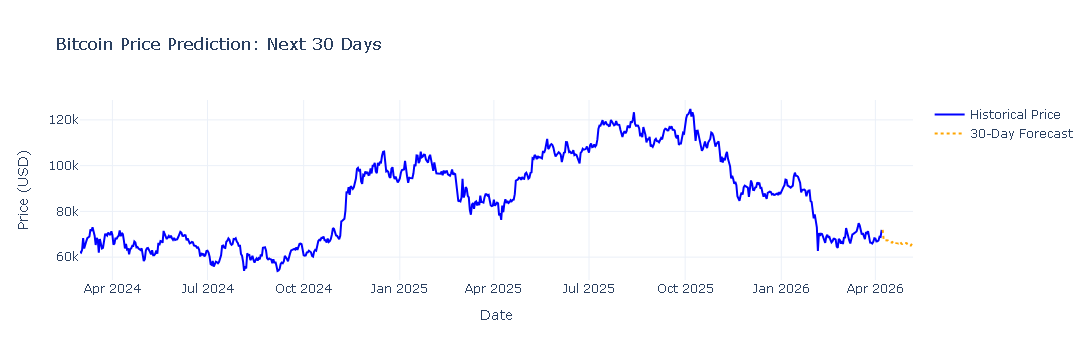

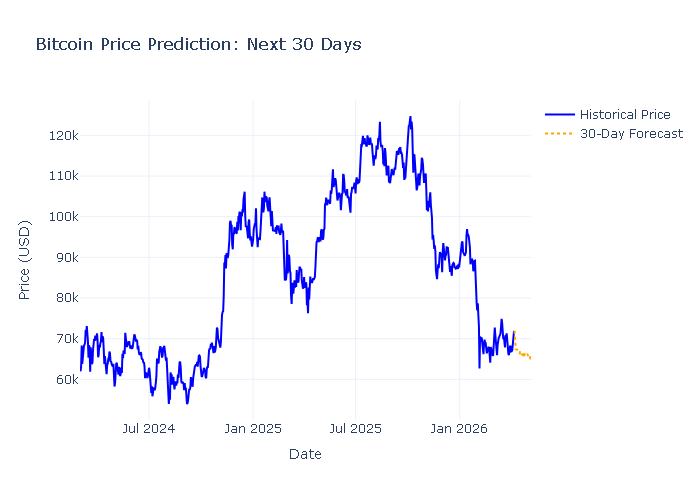

In [12]:
import plotly.graph_objects as go

fig = go.Figure()

# Plot Historical Data
fig.add_trace(go.Scatter(x=data['Date'], y=data['Close'], name='Historical Price', line=dict(color='blue')))

# Plot Forecasted Data
fig.add_trace(go.Scatter(x=forecast.index, y=forecast['Close'], name='30-Day Forecast', line=dict(color='orange', dash='dot')))

fig.update_layout(
    title='Bitcoin Price Prediction: Next 30 Days',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    template='plotly_white'
)
fig.show()
fig.show("png")

The AutoTS model has completed its evaluation of multiple time-series algorithms and generated a 30-day forecast. Based on the historical price patterns of BTC-USD, the model predicts a period of relative stability for early May 2026, with prices showing a downward correction from the current `$71k` level, followed by a period of price consolidation in the `$65k`- `$66k` range. This suggests that the model has identified a short-term 'overbought' signal in the historical data and expects the price to revert toward its recent mean.